In [2]:
#Task 1: Data Understanding
#1.1 Load the dataset using Pandas
import pandas as pd

url = "https://gist.githubusercontent.com/RobotOptimist/cc82e87e7d2104e58711b7c846a9e220/raw/Position_Salaries.csv"

df = pd.read_csv(url)

In [3]:
#1.3 Display last five records
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [4]:
#1.3 Identify the Input Feature and Target Variable
# Input Feature
X = df[['Level']]

# Target Variable
y = df['Salary']

print("Input Feature:")
print(X.head())

print("\nTarget Variable:")
print(y.head())

Input Feature:
   Level
0      1
1      2
2      3
3      4
4      5

Target Variable:
0     45000
1     50000
2     60000
3     80000
4    110000
Name: Salary, dtype: int64


In [5]:
#1.4 Display the dataset information and summary statistics
# Dataset Information
df.info()
# Summary Statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes


,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


In [6]:
#Task 2: Data Preprocessing
#2.1 Check for missing values
df.isnull().sum()

,0
Position,0
Level,0
Salary,0


In [ ]:
#2.2 Select the appropriate feature(s) and target variable
X = df[['Level']]
y = df['Salary']

In [7]:
#2.3 Split the dataset into 80% training and 20% testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (8, 1)
Testing Data Shape: (2, 1)


In [8]:
#Task 3: Model Development (3 Marks)
#3.1 Transform the input feature using Polynomial Features
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [9]:
#3.2 Train a Polynomial Regression model
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_poly, y_train)

LinearRegression()

In [10]:
#3.3 Predict salaries for the test dataset
y_pred = model.predict(X_test_poly)

print("Predicted Salaries:")
print(y_pred)

Predicted Salaries:
[606335.60051157  84934.89129171]


In [11]:
#Task 4: Model Evaluation
#4.1 Mean Absolute Error (MAE)
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 70635.24590164085


In [12]:
#4.2 Mean Squared Error (MSE)
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 6263853282.860292


In [13]:
#4.3 R² Score
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.8762695647830065


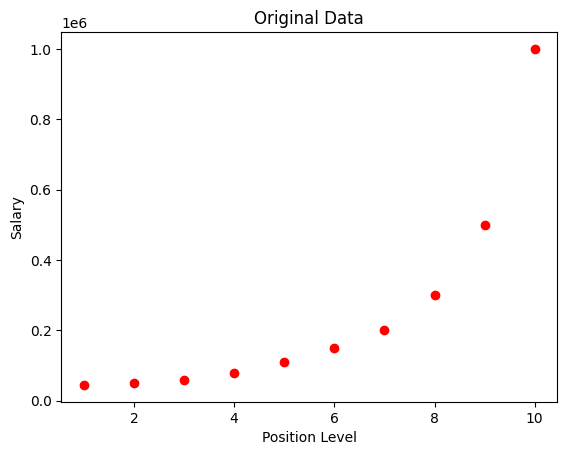

In [14]:
# Scatter Plot of Original Data
import matplotlib.pyplot as plt

plt.scatter(X, y, color='red')
plt.title("Original Data")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.show()

/tmp/ipykernel_1394/1663882454.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X.values), max(X.values), 0.1)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


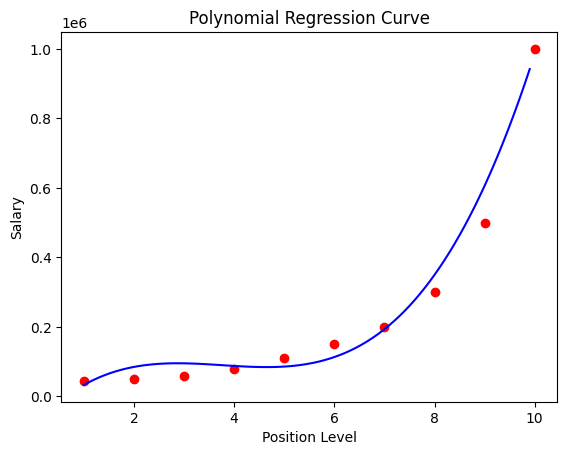

In [16]:
# Polynomial Regression Curve
import numpy as np

X_grid = np.arange(min(X.values), max(X.values), 0.1)
X_grid = X_grid.reshape(-1, 1)

plt.scatter(X, y, color='red')
plt.plot(X_grid, model.predict(poly.transform(X_grid)), color='blue')

plt.title("Polynomial Regression Curve")
plt.xlabel("Position Level")
plt.ylabel("Salary")
plt.show()